In [133]:
# Imports
import os
import sys
from IPython.display import display

from py_scripts.parser_registry import get_parse_files, list_parsers

# Backend selection ('music21' | 'partitura')
PARSING_BACKEND = 'partitura'

# Select parser function lazily by backend name
parse_files = get_parse_files(PARSING_BACKEND)

# Configuration
FILTER_ZERO_DURATION = True # filter out notes with duration 0 (grace notes)
ADJUST_FRACTIONAL_DURATION = True # rounds Duration, Local Onset, and Global Onset to 3 decimals
PARSE_ENHARMONIC = True     # add 'Pitch Enharmonic' column grounded in source notation
PLOTTING_BACKEND = 'bokeh'  # 'plt' | 'bokeh' | 'none'
SHOW_MEASURE_LINES = True   # draw red vertical lines at measure starts

DISPLAY_PREVIEW = True      # show a preview of the parsed data as df
PREVIEW_ROWS = 20          # number of rows to show in the preview

CLEANUP_REMOTE = True       # if source is a URL, delete temp file after parsing
RETURN_PLOTS = False        # include plot objects in results under 'plot'
STRIP_TIES = True           # merge tied notes into single notes (music21 backend only)

# List of file sources (URLs or local paths)
FILE_SOURCES = [
    #'https://analyse.hfm-weimar.de/database/02/PrJode_Jos0302_COM_1-5_MissaDapac_002_00006.xml',
    # 'https://raw.githubusercontent.com/humdrum-tools/bach-wtc-fugues/refs/heads/master/kern/wtc1f04.krn',
    # 'https://raw.githubusercontent.com/humdrum-tools/bach-wtc/refs/heads/main/kern/wtc1f22.krn',
    'https://raw.githubusercontent.com/piasteuck/winterreise-analysis/refs/heads/main/Schubert_Winterreise_Dataset_v2-0/01_RawData/score_musicxml/Schubert_D911-08.xml',
    'https://raw.githubusercontent.com/piasteuck/winterreise-analysis/refs/heads/main/Schubert_Winterreise_Dataset_v2-0/01_RawData/score_musicxml/Schubert_D911-20.xml',
    'https://raw.githubusercontent.com/piasteuck/winterreise-analysis/refs/heads/main/Schubert_Winterreise_Dataset_v2-0/01_RawData/score_musicxml/Schubert_D911-15.xml',
    'https://raw.githubusercontent.com/piasteuck/winterreise-analysis/refs/heads/main/Schubert_Winterreise_Dataset_v2-0/01_RawData/score_musicxml/Schubert_D911-07.xml',
    # 'https://raw.githubusercontent.com/music-encoding/sample-encodings/main/MEI_5.0/Music/Complete_examples/Bach-JS_Ein_feste_Burg.mei',
    # 'https://raw.githubusercontent.com/humdrum-tools/bach-wtc/refs/heads/main/kern/wtc2f05.krn',
    # 'C:/Users/egorp/OneDrive/Desktop/weimar_ftp_backup/dokuwiki/database/05/CaSe_11_UNSP_UNSP_Danksagenw_005_00011.xml'  # If you prefer backslashes, make it a raw string: r'C:\Users\egorp\...'
]

# Plot sizing
PLOT_SIZE_X = 900  # width in pixels
PLOT_SIZE_Y = 600   # height in pixels

# Zoom tool dimensions: 'both' | 'width' (x-only) | 'height' (y-only)
# Bokeh only!
ZOOM_DRAG_DIM = 'both'
ZOOM_WHEEL_DIM = 'width'

# Parse and visualize
results, dfs_by_name, df_processed = parse_files(
    FILE_SOURCES,
    filter_zero_duration=FILTER_ZERO_DURATION,
    adjust_fractional_duration=ADJUST_FRACTIONAL_DURATION,
    parse_enharmonic=PARSE_ENHARMONIC,
    backend=PLOTTING_BACKEND,
    show_measure_lines=SHOW_MEASURE_LINES,
    display_preview=DISPLAY_PREVIEW,
    preview_rows=PREVIEW_ROWS,
    cleanup_remote=CLEANUP_REMOTE,
    return_plots=RETURN_PLOTS,
    plot_width=PLOT_SIZE_X,
    plot_height=PLOT_SIZE_Y,
    zoom_drag_dim=ZOOM_DRAG_DIM,
    zoom_wheel_dim=ZOOM_WHEEL_DIM,
    strip_ties=STRIP_TIES,
)

# Show quick summary
print('Parsed DataFrames:')
for item in results:
    name = item['name']
    df = item['df']
    pos_dur = df.loc[df['Duration'] > 0, 'Duration'] if 'Duration' in df.columns else None
    min_dur_str = str(float(pos_dur.min())) if pos_dur is not None and len(pos_dur) > 0 else 'n/a'
    print(f"- {name}: rows={len(df)}, unique_pitches={df['MIDI'].nunique()}, min_duration={min_dur_str}")


Processing (partitura): Schubert_D911-08.xml -> 00_schubert_d911_08


c:\Users\sende\miniconda3\envs\camat_v2\Lib\site-packages\partitura\io\importmusicxml.py:1065: UserWarning: ignoring direction type: other-direction {'default-y': '-68', 'print-object': 'no'}
  warnings.warn("ignoring direction type: {} {}".format(dt.tag, dt.attrib))


,Measure,Local Onset,Global Onset,Duration,Pitch,Pitch Enharmonic,MIDI,Voice
0,1,0.00,0.00,0.50,G2,None,43,Piano - Voice 2
1,1,0.00,0.00,0.50,D3,None,50,Piano - Voice 1
2,1,0.25,0.25,0.25,G3,None,55,Piano - Voice 1
3,1,0.25,0.25,0.25,D4,None,62,Piano - Voice 1
4,1,0.50,0.50,0.50,A2,None,45,Piano - Voice 2
5,1,0.50,0.50,0.50,D3,None,50,Piano - Voice 1
6,1,0.75,0.75,0.25,A3,None,57,Piano - Voice 1
7,1,0.75,0.75,0.25,D4,None,62,Piano - Voice 1
8,1,1.00,1.00,0.50,A#2,None,46,Piano - Voice 2
9,1,1.00,1.00,0.50,D3,None,50,Piano - Voice 1


Rows: 2048, unique pitches: 41
Processing (partitura): Schubert_D911-20.xml -> 01_schubert_d911_20


c:\Users\sende\miniconda3\envs\camat_v2\Lib\site-packages\partitura\directions.py:514: UserWarning: error parsing "Mäßig" (UnexpectedCharacters)
  warnings.warn('error parsing "{}" ({})'.format(string, type(e).__name__))
c:\Users\sende\miniconda3\envs\camat_v2\Lib\site-packages\partitura\io\importmusicxml.py:1065: UserWarning: ignoring direction type: other-direction {'default-y': '14', 'print-object': 'no'}
  warnings.warn("ignoring direction type: {} {}".format(dt.tag, dt.attrib))
c:\Users\sende\miniconda3\envs\camat_v2\Lib\site-packages\partitura\io\importmusicxml.py:1065: UserWarning: ignoring direction type: other-direction {'default-y': '-53', 'print-object': 'no'}
  warnings.warn("ignoring direction type: {} {}".format(dt.tag, dt.attrib))


...

,Measure,Local Onset,Global Onset,Duration,Pitch,Pitch Enharmonic,MIDI,Voice
0,1,0.000,0.000,0.164,C4,None,60,Piano - Voice 2
1,1,0.000,0.000,0.500,C6,None,84,Piano - Voice 1
2,1,0.164,0.164,0.168,D#4,None,63,Piano - Voice 2
3,1,0.332,0.332,0.168,G4,None,67,Piano - Voice 2
4,1,0.500,0.500,0.164,D4,None,62,Piano - Voice 2
5,1,0.500,0.500,0.500,B5,None,83,Piano - Voice 1
6,1,0.664,0.664,0.168,F4,None,65,Piano - Voice 2
7,1,0.832,0.832,0.168,G4,None,67,Piano - Voice 2
8,1,1.000,1.000,0.164,D#4,None,63,Piano - Voice 2
9,1,1.000,1.000,0.500,C6,None,84,Piano - Voice 1


Rows: 739, unique pitches: 50
Processing (partitura): Schubert_D911-07.xml -> 03_schubert_d911_07


c:\Users\sende\miniconda3\envs\camat_v2\Lib\site-packages\partitura\directions.py:514: UserWarning: error parsing "Langsam." (UnexpectedCharacters)
  warnings.warn('error parsing "{}" ({})'.format(string, type(e).__name__))
c:\Users\sende\miniconda3\envs\camat_v2\Lib\site-packages\partitura\io\importmusicxml.py:1065: UserWarning: ignoring direction type: metronome {'default-y': '30', 'color': '#000000', 'font-family': 'Plantin MT Std', 'font-style': 'italic', 'font-size': '9.3012', 'font-weight': 'bold'}
  warnings.warn("ignoring direction type: {} {}".format(dt.tag, dt.attrib))
c:\Users\sende\miniconda3\envs\camat_v2\Lib\site-packages\partitura\directions.py:514: UserWarning: error parsing "(sehr leise)" (UnexpectedCharacters)
  warnings.warn('error parsing "{}" ({})'.format(string, type(e).__name__))
c:\Users\sende\miniconda3\envs\camat_v2\Lib\site-packages\partitura\io\importmusicxml.py:1614: UserWarning: Tuplet start and end notes do not belong to the same voice (2 != 1). This migh

,Measure,Local Onset,Global Onset,Duration,Pitch,Pitch Enharmonic,MIDI,Voice
0,1,0.0,0.0,0.5,E3,None,52,Piano - Voice 2
1,1,0.5,0.5,0.5,B3,None,59,Piano - Voice 1
2,1,0.5,0.5,0.5,E4,None,64,Piano - Voice 1
3,1,0.5,0.5,0.5,G4,None,67,Piano - Voice 1
4,1,1.0,1.0,0.5,D3,None,50,Piano - Voice 2
5,1,1.5,1.5,0.5,B3,None,59,Piano - Voice 1
6,1,1.5,1.5,0.5,E4,None,64,Piano - Voice 1
7,1,1.5,1.5,0.5,G4,None,67,Piano - Voice 1
8,1,2.0,2.0,0.5,C3,None,48,Piano - Voice 2
9,1,2.5,2.5,0.5,C4,None,60,Piano - Voice 1


Rows: 1330, unique pitches: 42
Parsed DataFrames:
- 00_schubert_d911_08: rows=2048, unique_pitches=41, min_duration=0.25
- 01_schubert_d911_20: rows=1131, unique_pitches=43, min_duration=0.125
- 02_schubert_d911_15: rows=739, unique_pitches=50, min_duration=0.125
- 03_schubert_d911_07: rows=1330, unique_pitches=42, min_duration=0.125


In [134]:
list(dfs_by_name)


['00_schubert_d911_08',
 '01_schubert_d911_20',
 '02_schubert_d911_15',
 '03_schubert_d911_07']

In [135]:

list(FILE_SOURCES)

['https://raw.githubusercontent.com/piasteuck/winterreise-analysis/refs/heads/main/Schubert_Winterreise_Dataset_v2-0/01_RawData/score_musicxml/Schubert_D911-08.xml',
 'https://raw.githubusercontent.com/piasteuck/winterreise-analysis/refs/heads/main/Schubert_Winterreise_Dataset_v2-0/01_RawData/score_musicxml/Schubert_D911-20.xml',
 'https://raw.githubusercontent.com/piasteuck/winterreise-analysis/refs/heads/main/Schubert_Winterreise_Dataset_v2-0/01_RawData/score_musicxml/Schubert_D911-15.xml',
 'https://raw.githubusercontent.com/piasteuck/winterreise-analysis/refs/heads/main/Schubert_Winterreise_Dataset_v2-0/01_RawData/score_musicxml/Schubert_D911-07.xml']

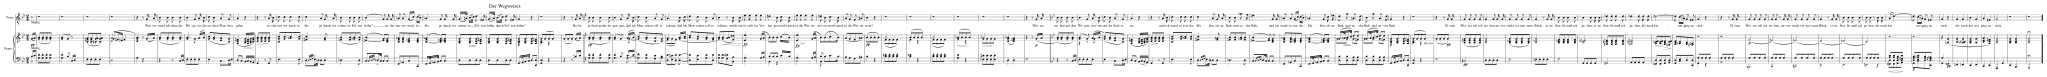

In [136]:
from py_scripts import (
    vrv_set_options, vrv_load_from_url, vrv_render_all_pages, vrv_display_svg
)

url = FILE_SOURCES[1]

vrv_set_options(pageWidth=12000, pageHeight=1200, scale=40, breaks="none")
_ = vrv_load_from_url(url)  # auto detects 'mei' | 'musicxml' | 'humdrum'
for svg in vrv_render_all_pages():
    vrv_display_svg(svg)

In [137]:
df1 = results[0]['df']
df2 = results[1]['df']

display(df1)
display(df2)

,Measure,Local Onset,Global Onset,Duration,Pitch,Pitch Enharmonic,MIDI,Voice
0,1,0.00,0.00,0.50,G2,None,43,Piano - Voice 2
1,1,0.00,0.00,0.50,D3,None,50,Piano - Voice 1
2,1,0.25,0.25,0.25,G3,None,55,Piano - Voice 1
3,1,0.25,0.25,0.25,D4,None,62,Piano - Voice 1
4,1,0.50,0.50,0.50,A2,None,45,Piano - Voice 2
...,...,...,...,...,...,...,...,...
2043,1,204.50,204.50,3.00,G1,None,31,Piano - Voice 2
2044,1,204.50,204.50,3.00,G2,None,43,Piano - Voice 1
2045,1,204.50,204.50,3.00,B3,None,59,Piano - Voice 1
2046,1,204.50,204.50,3.00,D4,None,62,Piano - Voice 1


,Measure,Local Onset,Global Onset,Duration,Pitch,Pitch Enharmonic,MIDI,Voice
0,1,1.50,-0.50,0.25,A#3,None,58,Piano - Voice 4
1,1,1.50,-0.50,0.25,G4,None,67,Piano - Voice 1
2,1,1.75,-0.25,0.25,C4,None,60,Piano - Voice 4
3,1,1.75,-0.25,0.25,A4,None,69,Piano - Voice 1
4,1,0.00,0.00,0.50,G3,None,55,Piano - Voice 4
...,...,...,...,...,...,...,...,...
1126,2,163.00,163.00,1.00,G4,None,67,Piano - Voice 1
1127,2,164.00,164.00,2.00,G1,None,31,Piano - Voice 4
1128,2,164.00,164.00,2.00,A#3,None,58,Piano - Voice 1
1129,2,164.00,164.00,2.00,D4,None,62,Piano - Voice 1


In [138]:
display(df2.loc[df2['Pitch Enharmonic'].eq('Db5')]) # partitura, flats are represented as follows: "Db5"
display(df2.loc[df2['Pitch Enharmonic'].eq('D-5')]) # music21, flats are represented as follows: "D-5"

df2['Pitch Enharmonic'].unique() # Show all unique enharmonic pitches


,Measure,Local Onset,Global Onset,Duration,Pitch,Pitch Enharmonic,MIDI,Voice


,Measure,Local Onset,Global Onset,Duration,Pitch,Pitch Enharmonic,MIDI,Voice


array([None], dtype=object)

In [139]:
# Showcase: filtering/selecting from a notes DataFrame + piano-roll plot
# - by Global Onset range
# - by Measure range
# - by Voice(s)
# - plot a piano roll of the selection using py_scripts.music_utils

import pandas as pd
from IPython.display import display
from py_scripts.music_utils import draw_piano_roll

# Pick which parsed DataFrame to work with (e.g., df1 or df2 from above)
source_df = df2  # change to df1 to use the other score

# 1) Select by Global Onset range [lo, hi)
global_onset_lo, global_onset_hi = 0.0, 32.0
selected_by_onset = source_df[(source_df['Global Onset'] >= global_onset_lo) & (source_df['Global Onset'] < global_onset_hi)].copy()
print(f"Rows in Global Onset [{global_onset_lo}, {global_onset_hi}): {len(selected_by_onset)}")
display(selected_by_onset.head())

# 2) Select by Measure range (inclusive)
measure_lo, measure_hi = 1, 4
selected_by_measure = source_df[(source_df['Measure'] >= measure_lo) & (source_df['Measure'] <= measure_hi)].copy()
print(f"Rows in Measure [{measure_lo}, {measure_hi}]: {len(selected_by_measure)}")
display(selected_by_measure.head())

# 3) Voice exploration + filtering
voices_available = sorted(source_df['Voice'].dropna().unique().tolist())
print("Unique Voice types:")
display(pd.Series(voices_available, name='Voice types'))

# Filter by a specific voice label pattern (example: Voice 2)
voice_regex = r"Voice 2"  # matches 'Voice 2' within labels like 'P0 - Voice 2'
voice_filtered = source_df[source_df['Voice'].str.contains(voice_regex, regex=True, na=False)].copy()
print(f"Rows matching voices ~ /{voice_regex}/: {len(voice_filtered)}")
display(voice_filtered.head())

# Combine: onset window AND voice filter
selection = selected_by_onset[selected_by_onset['Voice'].str.contains(voice_regex, regex=True, na=False)].copy()
if selection.empty:
    # Fallback: if no notes match the voice in this time window, just show the time window
    selection = selected_by_onset
print(f"Final selection rows (combined filters where possible): {len(selection)}")

# Measure guide lines for selected window
# Prefer parser-provided measure_offsets if available for this source
try:
    res_idx = next((i for i, item in enumerate(results) if item.get('df') is source_df), None)
except Exception:
    res_idx = None

if res_idx is not None and isinstance(res_idx, int) and res_idx >= 0 and res_idx < len(results) and 'measure_offsets' in results[res_idx]:
    measure_offsets_full = list(results[res_idx]['measure_offsets'])
else:
    measure_offsets_full = (
        source_df.groupby('Measure')['Global Onset'].min().sort_values().tolist()
    )

# Compute extended right bound to include full duration of last note in selection
try:
    selection_end = float((selection['Global Onset'] + selection['Duration']).max())
except Exception:
    selection_end = None
extended_hi = max(global_onset_hi, selection_end) if selection_end is not None else global_onset_hi

# Restrict to the visible window [lo, extended_hi], inclusive of the right boundary
eps = 1e-6
visible_measure_offsets = [m for m in measure_offsets_full if (m >= global_onset_lo - eps) and (m <= extended_hi + eps)]
# Deduplicate with rounding for stability
if visible_measure_offsets:
    visible_measure_offsets = sorted({round(float(m), 6) for m in visible_measure_offsets})

# 4) Piano roll for the selection (uses existing utility; backend honors global PLOTTING_BACKEND)
backend = (PLOTTING_BACKEND.lower() if 'PLOTTING_BACKEND' in globals() else 'plt')
draw_piano_roll(
    selection,
    measure_offsets=visible_measure_offsets,
    backend=backend,
    plot_width=(PLOT_SIZE_X if 'PLOT_SIZE_X' in globals() else None),
    plot_height=(PLOT_SIZE_Y if 'PLOT_SIZE_Y' in globals() else None),
    zoom_drag_dim=ZOOM_DRAG_DIM,
    zoom_wheel_dim=ZOOM_WHEEL_DIM,
    show_measure_lines=True,
)

Rows in Global Onset [0.0, 32.0): 233


,Measure,Local Onset,Global Onset,Duration,Pitch,Pitch Enharmonic,MIDI,Voice
4,1,0.0,0.0,0.5,G3,None,55,Piano - Voice 4
5,1,0.0,0.0,0.5,D4,None,62,Piano - Voice 1
6,1,0.0,0.0,0.5,G4,None,67,Piano - Voice 1
7,1,0.0,0.0,0.5,A#4,None,70,Piano - Voice 1
8,1,0.5,0.5,0.5,G3,None,55,Piano - Voice 4


Rows in Measure [1, 4]: 1131


,Measure,Local Onset,Global Onset,Duration,Pitch,Pitch Enharmonic,MIDI,Voice
0,1,1.50,-0.50,0.25,A#3,None,58,Piano - Voice 4
1,1,1.50,-0.50,0.25,G4,None,67,Piano - Voice 1
2,1,1.75,-0.25,0.25,C4,None,60,Piano - Voice 4
3,1,1.75,-0.25,0.25,A4,None,69,Piano - Voice 1
4,1,0.00,0.00,0.50,G3,None,55,Piano - Voice 4


Unique Voice types:


0    Piano - Voice 1
1    Piano - Voice 2
2    Piano - Voice 3
3    Piano - Voice 4
4    Piano - Voice 5
5    Voice - Voice 1
Name: Voice types, dtype: object

Rows matching voices ~ /Voice 2/: 34


,Measure,Local Onset,Global Onset,Duration,Pitch,Pitch Enharmonic,MIDI,Voice
46,1,0.00,6.00,0.50,G4,None,67,Piano - Voice 2
48,1,0.50,6.50,0.25,F#4,None,66,Piano - Voice 2
49,1,0.75,6.75,0.25,E4,None,64,Piano - Voice 2
50,1,1.00,7.00,1.00,F#4,None,66,Piano - Voice 2
82,1,1.50,13.50,0.50,G4,None,67,Piano - Voice 2


Final selection rows (combined filters where possible): 5


In [140]:
# Refactored pitch distribution using py_scripts.analysis_utils
from py_scripts import display_pitch_distribution

# Configuration for this cell (all lowercase options)
#
# PITCH_X_AXIS controls which pitch representation is used on the X axis:
#   - 'midi': use numeric MIDI values. If 'MIDI' column is missing, it is derived from names.
#   - 'pitch real' (synonyms: 'pitch', 'real'): use real pitch names corresponding to actual semitone values;
#       if only MIDI is present, names are derived from MIDI. Octave is included in the label.
#   - 'pitch enharmonic' (synonyms: 'pitch by name', 'pitch name', 'name', 'pitch_enharmonic', 'pitch-enharmonic'):
#       use written/enharmonic pitch names as notated (prefers 'Pitch Enharmonic' column),
#       preserving the spelled accidentals and octave, even if enharmonically different from real pitch.
PITCH_X_AXIS = 'pitch enharmonic'
#
# ORDER_X_AXIS_BY controls sort order of the X categories:
#   - 'midi' (synonyms: 'pitch real', 'pitch', 'real'):
#       sort by real MIDI number ascending (identical for all synonyms).
#   - 'pitch by octave real' (synonyms: 'pitch by octave', 'pitch octave', 'octave pitch', 'octave real'):
#       sort by REAL octave (computed from MIDI), then by pitch class within each octave.
#       This cares about actual pitch height. Example: B##3 resolves to its real octave (4); Cbb4 resolves to 3.
#   - 'pitch by octave enharmonic' (synonyms: 'octave enharmonic', 'octave name'):
#       sort by WRITTEN octave parsed from the name (ignoring semitone shifts of accidentals),
#       then by letter and accidental. Example: B##3 stays in octave 3; Cbb4 stays in octave 4.
#   - 'pitch by name' (synonyms: 'pitch enharmonic', 'enharmonic', 'enharmonic pitch', 'pitch_enharmonic'):
#       sort by letter (C..B) and accidental rank (bbb < bb < b < natural < # < ## < ###),
#       ignoring octave; ties are stabilized by the full label.
ORDER_X_AXIS_BY = 'pitch by name'

# Plotting backend
PLOTTING_BACKEND = 'bokeh'        # 'plt' | 'bokeh' | 'none'

# Plot sizing for this cell (universal for both backends)
PLOT_SIZE_X = 1200
PLOT_SIZE_Y = 600

# Bokeh hover config
BOKEH_HOVER_VALUES = True

# Choose the DataFrame to visualize
source = selection  # e.g., df1, results[0]['df'], dfs_by_name['00_some_name'] or a selection from df

counts_df = display_pitch_distribution(
    source,
    pitch_axis=PITCH_X_AXIS,
    order_axis_by=ORDER_X_AXIS_BY,
    backend=(PLOTTING_BACKEND.lower() if 'PLOTTING_BACKEND' in globals() else 'plt'),
    plot_width=PLOT_SIZE_X,
    plot_height=PLOT_SIZE_Y,
    show_hover=('BOKEH_HOVER_VALUES' in globals() and BOKEH_HOVER_VALUES),
    show_table=False,
)

Loading BokehJS ...

In [141]:
# Duration distribution: count and visualize as bar plot (plt or bokeh)
# Uses global PLOTTING_BACKEND ('plt' or 'bokeh')

import numpy as np
import pandas as pd

# Configuration for this cell
DROP_ZERO_DURATIONS = True          # drop duration == 0
DURATION_ROUND_DECIMALS = 4         # round durations for cleaner categories; set None to disable

# Ensure df1 exists
if 'df1' not in globals():
    df1 = results[2]['df']

# Detect duration column
duration_col = None
for candidate in ['Duration', 'duration', 'durations', 'Durations']:
    if candidate in df1.columns:
        duration_col = candidate
        break

if duration_col is None:
    print("No duration column found. Checked: 'Duration', 'duration', 'durations', 'Durations'.")
else:
    ser = df1[duration_col].copy()
    # Coerce to numeric where possible
    ser = pd.to_numeric(ser, errors='coerce')
    ser = ser.dropna()
    if DROP_ZERO_DURATIONS:
        ser = ser[ser != 0]
    if DURATION_ROUND_DECIMALS is not None:
        ser = ser.round(DURATION_ROUND_DECIMALS)

    # Aggregate and sort by numeric value (ascending)
    counts = ser.value_counts().sort_index()

    # Display table
    display(counts.rename('count').to_frame())

    backend = (PLOTTING_BACKEND.lower() if 'PLOTTING_BACKEND' in globals() else 'plt')

    x_vals = counts.index.astype(str).tolist()
    y_vals = counts.values.tolist()

    if backend == 'plt':
        import matplotlib.pyplot as plt
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.bar(x_vals, y_vals, color='seagreen')
        ax.set_xlabel(duration_col)
        ax.set_ylabel('Count')
        ax.set_title('Duration Distribution')
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()

    elif backend == 'bokeh':
        from bokeh.plotting import figure, show
        from bokeh.io import output_notebook
        from bokeh.models import ColumnDataSource
        output_notebook()

        source = ColumnDataSource(dict(x=x_vals, count=y_vals))
        p = figure(x_range=x_vals, height=350, width=900, title='Duration Distribution', toolbar_location='right')
        p.vbar(x='x', top='count', width=0.9, source=source, fill_color='#2E8B57')
        p.xaxis.axis_label = duration_col
        p.yaxis.axis_label = 'Count'
        p.xgrid.grid_line_color = None
        p.y_range.start = 0
        show(p)

    else:
        print(f"Unsupported plotting backend: {backend}. Use 'plt' or 'bokeh'.")



,count
Duration,
0.250,1000
0.332,4
0.336,2
0.500,953
0.750,4
1.000,63
1.500,2
2.000,8
2.500,1


Loading BokehJS ...

to do: enharmonic, intervall plot, combined plots